In [19]:
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [20]:
class CHIMEFRBDataset(Dataset):
    def __init__(self, hdf5_path, catalog_path, target_length):
        self.hdf5_path = hdf5_path
        self.dt = 0.009830400085775182*1000

        self.target_length = target_length
        cat = pd.read_csv(catalog_path, low_memory=False)
        cat["repeater_name"] = cat["repeater_name"].fillna("").str.strip()
        self.repeater_set = set(
            cat.loc[cat["repeater_name"] != "", "tns_name"].str.strip()
        )
        with h5py.File(hdf5_path, "r") as f:
            self.keys = list(f.keys())

        
    @staticmethod
    def _pad_or_crop(wfall, target_length, center_idx):
        n_freq, n_time = wfall.shape
        half = target_length // 2
        start = center_idx - half
        end = start + target_length
        
        if start >= 0 and end <= n_time:
            return wfall[:, start:end]         
        
        src_start = max(start, 0)
        src_end = min(end, n_time)
        out = np.zeros((n_freq, target_length), dtype=wfall.dtype)
        dst_start = src_start - start
        out[:, dst_start:dst_start + (src_end - src_start)] = wfall[:, src_start:src_end]
        return out
    
    
    def __len__(self):
        return len(self.keys)
    
    
    def __getitem__(self, idx):
        key = self.keys[idx]
        
        with h5py.File(self.hdf5_path, "r") as f:
            wfall = f[key]["wfall_plot"][:]
            extent = np.array(f[key]["extent"])
            
        wfall = wfall.astype(np.float32)
        std = wfall.std(axis=1, keepdims=True)
        std[std == 0] = 1.0          # avoid divide-by-zero for masked channels
        wfall = (wfall - wfall.mean(axis=1, keepdims=True)) / std
        

        peak = round(-extent[0] / self.dt)
        wfall = self._pad_or_crop(wfall, self.target_length, peak)
        tensor = torch.from_numpy(wfall)
        label = torch.tensor(int(key in self.repeater_set), dtype=torch.long)
        
        return tensor, label



In [ ]:
def make_dataloader(
    hdf5_path: str,
    catalog_path: str,
    target_length: int,
    batch_size: int = 32,
    shuffle: bool = True,
    num_workers: int = 0,
    train_frac: float = 0.8,
    seed: int = 42,
):
    dataset = CHIMEFRBDataset(hdf5_path, catalog_path, target_length)

    n_total = len(dataset)
    n_train = int(n_total * train_frac)
    n_val = n_total - n_train

    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val], generator=generator
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    # Print class balance
    labels = [dataset[i][1].item() for i in range(n_total)]
    n_rep = sum(labels)
    print(f"Dataset: {n_total} bursts | {n_rep} repeaters ({100*n_rep/n_total:.1f}%) "
          f"| {n_total-n_rep} non-repeaters")
    print(f"Train: {n_train} | Val: {n_val}")

    return train_loader, val_loader

In [22]:
TARGET_LENGTH = 128 

train_loader, val_loader = make_dataloader(
    hdf5_path="all_bursts.hdf5",
    catalog_path="chimefrbcat2.csv",
    target_length=TARGET_LENGTH,
    batch_size=32,
    num_workers=0,
)

# Sanity check
for wfall_batch, label_batch in train_loader:
    print(f"Batch shape : {wfall_batch.shape}")
    print(f"Labels      : {label_batch}")
    break


Dataset: 4536 bursts | 981 repeaters (21.6%) | 3555 non-repeaters
Train: 3628 | Val: 908
Batch shape : torch.Size([32, 256, 128])
Labels      : tensor([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
        1, 0, 0, 0, 1, 0, 0, 1])


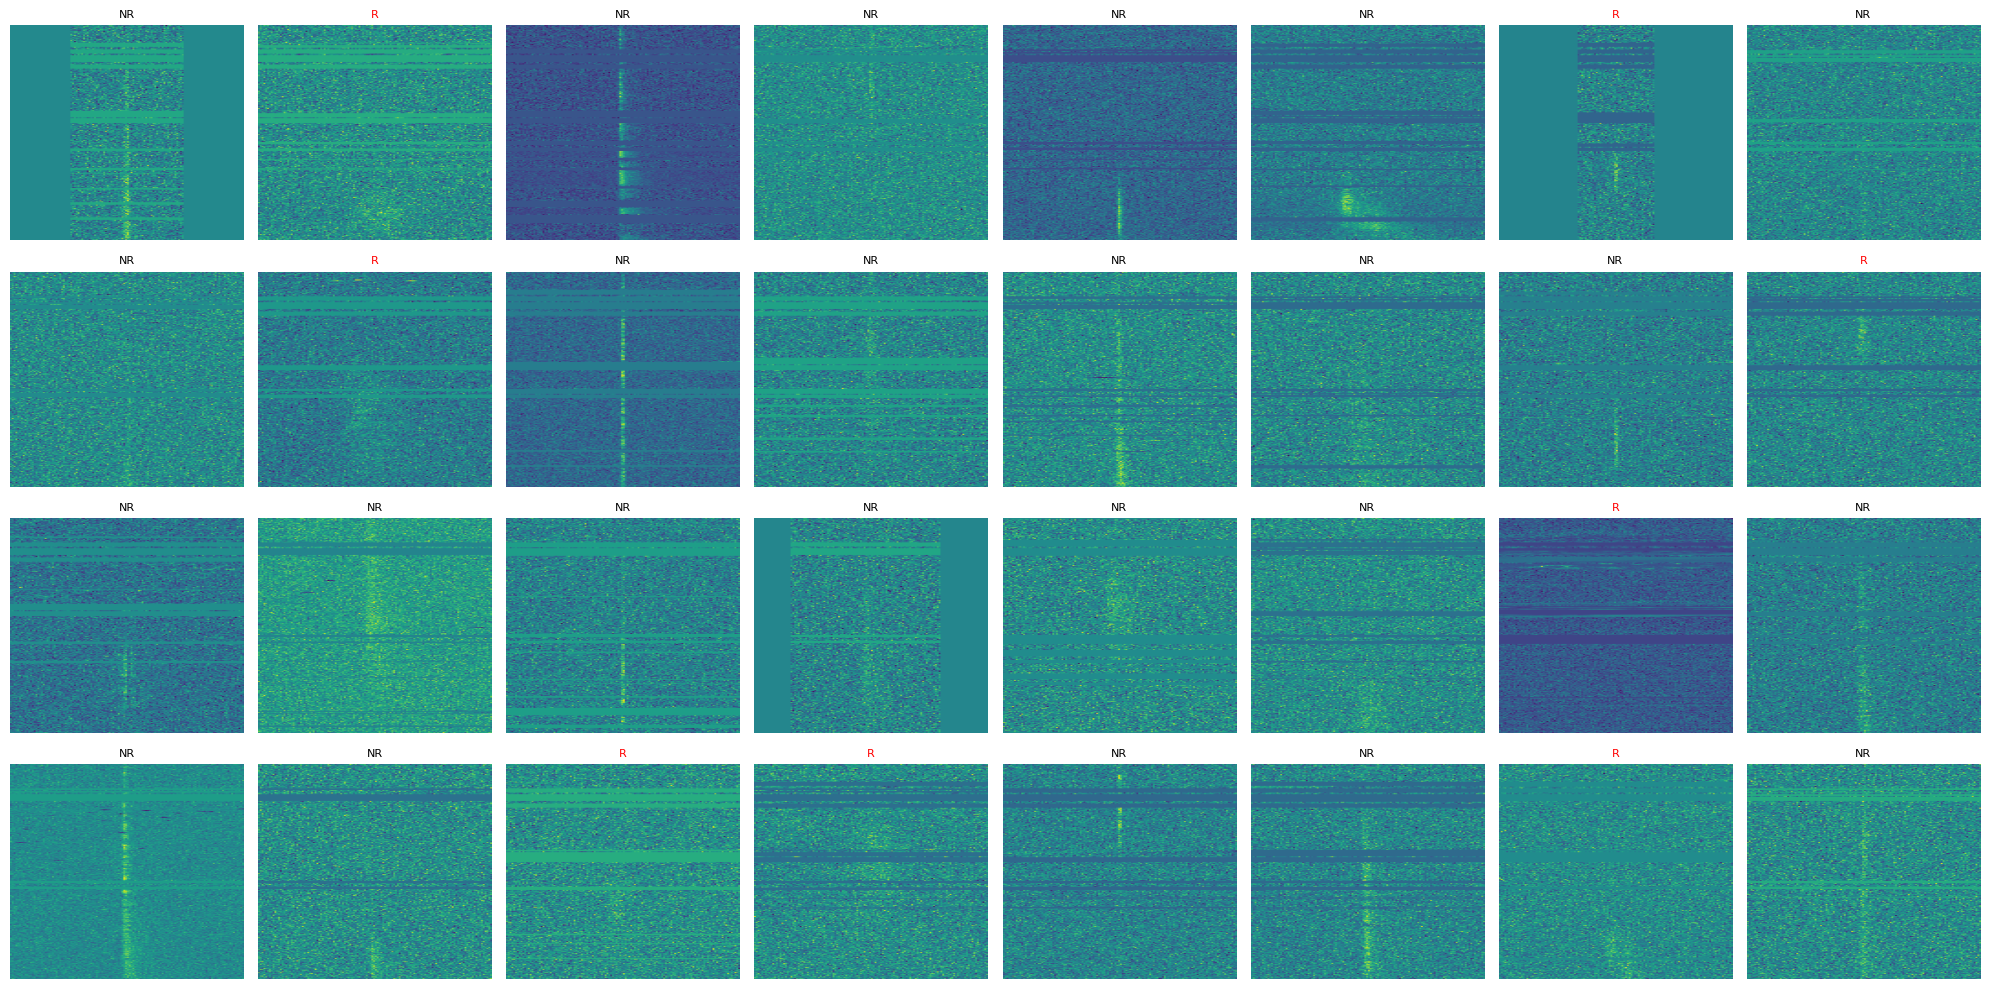

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    wfall, label = train_loader.dataset[i]
    ax.imshow(wfall, aspect="auto", origin="lower")
    ax.set_title("R" if label else "NR", fontsize=8, color="red" if label else "black")
    ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
N_FREQ       = 256
N_TIME       = TARGET_LENGTH
EMBED_DIM    = 64    # projected embedding size
N_HEADS      = 4
N_LAYERS     = 2
MLP_DIM      = 128
MASK_RATIO   = 0.25  # fraction of timesteps to mask
N_CLASSES    = 2     # repeater / non-repeater


class SinusoidalPE(nn.Module):
    def __init__(self, seq_len, embed_dim):
        super().__init__()
        pe = torch.zeros(seq_len, embed_dim)
        pos = torch.arange(seq_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, embed_dim, 2) * (-np.log(10000) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe  # broadcast over batch


def random_mask(batch_size, seq_len, mask_ratio, device):
    n_mask = int(seq_len * mask_ratio)
    mask = torch.zeros(batch_size, seq_len, dtype=torch.bool, device=device)
    for i in range(batch_size):
        idx = torch.randperm(seq_len, device=device)[:n_mask]
        mask[i, idx] = True
    return mask


class MaskedTransformer(nn.Module):

    def __init__(self):
        super().__init__()

        self.embed = nn.Linear(N_FREQ, EMBED_DIM)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
        self.pos_enc = SinusoidalPE(N_TIME, EMBED_DIM)  # +1 for CLS
        self.mask_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=EMBED_DIM, nhead=N_HEADS,
            dim_feedforward=MLP_DIM, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=N_LAYERS)

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=EMBED_DIM, nhead=N_HEADS,
            dim_feedforward=MLP_DIM, batch_first=True
        )
        self.decoder = nn.TransformerEncoder(decoder_layer, num_layers=1)

        self.cls_head = nn.Linear(EMBED_DIM, 1)
        self.recon_head = nn.Linear(EMBED_DIM, N_FREQ)
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.mask_token, std=0.02)

    def forward(self, wfall):
        batch = wfall.shape[0]
        device = wfall.device

        tokens = self.embed(wfall.permute(0, 2, 1))
        tokens = self.pos_enc(tokens)      

        mask = random_mask(batch, N_TIME, MASK_RATIO, device)

        unmasked_tokens = [tokens[i][~mask[i]] for i in range(batch)]
        unmasked_tokens = torch.stack(unmasked_tokens) 

        cls = self.cls_token.expand(batch, -1, -1)
        enc_input = torch.cat([cls, unmasked_tokens], dim=1)
        encoded = self.encoder(enc_input)                    

        cls_out         = encoded[:, 0, :]                   
        encoded_tokens  = encoded[:, 1:, :]                  

        mask_tokens = self.mask_token.expand(batch, N_TIME, -1).clone()
        full = mask_tokens.clone()
        for i in range(batch):
            full[i][~mask[i]] = encoded_tokens[i]            

        decoded = self.decoder(full)                         

        logits = self.cls_head(cls_out)                      
        recon  = self.recon_head(decoded)                    
        return logits, recon, mask


def compute_loss(logits, recon, mask, wfall, labels, alpha=1.0, beta=1.0, pos_weight=None, device='cpu'):
    pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32, device=device) if pos_weight else None
    cls_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)(logits.squeeze(1), labels.float())

    target = wfall.permute(0, 2, 1)
    diff = (recon - target) ** 2
    recon_loss = diff[mask].mean()

    return alpha * cls_loss + beta * recon_loss, cls_loss, recon_loss


def train_one_epoch(model, loader, optimiser, device):
    model.train()
    total, correct = 0, 0
    running_loss = running_cls = running_recon = 0.0

    for wfall, labels in loader:
        wfall, labels = wfall.to(device), labels.to(device)

        logits, recon, mask = model(wfall)
        loss, cls_loss, recon_loss = compute_loss(logits, recon, mask, wfall, labels)

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        running_loss  += loss.item()
        running_cls   += cls_loss.item()
        running_recon += recon_loss.item()

        preds = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    n = len(loader)
    print(f"  loss={running_loss/n:.4f}  cls={running_cls/n:.4f}  "
          f"recon={running_recon/n:.4f}  acc={correct/total:.3f}")


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total, correct = 0, 0
    for wfall, labels in loader:
        wfall, labels = wfall.to(device), labels.to(device)
        logits, _, _ = model(wfall)
        preds = (torch.sigmoid(logits.squeeze(1)) > 0.5).long()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    print(f"  val acc={correct/total:.3f}")


device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = MaskedTransformer().to(device)
optimiser = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCHS = 10
for epoch in range(N_EPOCHS):
    print(f"Epoch {epoch+1}/{N_EPOCHS}")
    train_one_epoch(model, train_loader, optimiser, device)
    evaluate(model, val_loader, device)

Epoch 1/10
  loss=1.4379  cls=0.5228  recon=0.9151  acc=0.781
  val acc=0.785
Epoch 2/10
  loss=1.3583  cls=0.4764  recon=0.8818  acc=0.791
  val acc=0.806
Epoch 3/10
  loss=1.2739  cls=0.3978  recon=0.8761  acc=0.825
  val acc=0.834
Epoch 4/10
  loss=1.2372  cls=0.3663  recon=0.8709  acc=0.849
  val acc=0.831
Epoch 5/10
  loss=1.2033  cls=0.3333  recon=0.8700  acc=0.868
  val acc=0.825
Epoch 6/10
  loss=1.1813  cls=0.3106  recon=0.8706  acc=0.870
  val acc=0.854
Epoch 7/10
  loss=1.1512  cls=0.2844  recon=0.8668  acc=0.889
  val acc=0.822
Epoch 8/10
  loss=1.1398  cls=0.2751  recon=0.8647  acc=0.896
  val acc=0.834
Epoch 9/10
  loss=1.1334  cls=0.2639  recon=0.8695  acc=0.898
  val acc=0.819
Epoch 10/10
  loss=1.1066  cls=0.2401  recon=0.8665  acc=0.912
  val acc=0.827
